# Minimal validation: 3-sector extension
Checks that the model initializes, finds the steady state, and that the
extension-specific quantities (two tradeable sectors, inner flat-CES nest,
sector-specific material costs) are internally consistent.  
Uses `T=100` to keep runtime short.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import os
# GEModelTools and EconModel are local packages — add to path if not already installed
if r'c:\Users\kons-ana\GEModelTools' not in sys.path:
    sys.path.insert(0, r'c:\Users\kons-ana\GEModelTools')
from IHANKModel import IHANKModelClass

model = IHANKModelClass(name='test')
model.par.T = 100   # reduce horizon for speed
par = model.par
ss  = model.ss

## 1. Steady state

In [2]:
model.find_ss(do_print=True)

household problem in ss solved in 6.7 secs [376 iterations]
household problem in ss simulated in 6.3 secs [409 iterations]
steady state found in 14.0 secs
ss.inc_HH = 0.266
ss.inc_HL = 0.133
ss.inc_NT = 0.301
par.alphaT = 0.810
par.alphaF = 0.333
par.omega_TH_H = 0.657
par.varphiHH = 1.271
par.varphiHL = 1.271
par.varphiNT = 1.271
ss.YHH = 0.559
ss.YHL = 0.292
ss.YNT = 0.430
ss.M_eu_s = 0.236
ss.M_us_s = 0.236
ss.clearing_YHH =   0.00000000
ss.clearing_YHL =  -0.00000000
ss.clearing_YNT =   0.00000000
ss.G = 0.296
ss.NFA = 0.000
ss.CB = 0.005
ss.CB_us = 1.000


In [3]:
# Built-in GEModelTools residual check
model.test_ss()

E              :       1.0000
CB             :       0.0050
E_us           :       1.0000
CB_us          :       1.0000
piM_eu_eu      :       0.0000
piM_us_us      :       0.0000
PM_eu_eu       :       1.0000
PM_us_us       :       1.0000
PM_eu_us       :       1.0000
PM_eu          :       1.0000
PM_us_eu       :       1.0000
PM_us          :       1.0000
PM_dk_eu       :       1.0000
PM_dk_us       :       1.0000
tau_m          :       0.0000
tau_x          :       0.0000
Z_eu           :       1.0000
i_shock_eu     :       0.0000
Y_eu           :       1.1111
C_eu           :       1.0000
N_eu           :       1.0000
pi_eu          :       0.0000
i_eu           :       0.0050
PF_eu_s        :       1.0000
rF_eu          :       0.0050
M_eu_s         :       0.2356
mc_eu          :       1.0000
W_eu           :       1.0000
M_eu           :       0.1111
M_eu_eu        :       0.1000
M_eu_us        :       0.0111
eu_Euler_res   :       0.0000
eu_LS_res      :       0.0000
eu_NKPC_re

## 2. Extension-specific steady-state checks

In [4]:
sNT = 1.0 - par.sHH - par.sHL
tol = 1e-8

checks = {}

# --- calibrated parameters are sensible ---
checks['0 < omega_TH_H < 1'] = 0 < par.omega_TH_H < 1
checks['0 < alphaT < 1']     = 0 < par.alphaT < 1
checks['varphiHH > 0']       = par.varphiHH > 0
checks['varphiHL > 0']       = par.varphiHL > 0
checks['varphiNT > 0']       = par.varphiNT > 0

# --- sectors are actually differentiated ---
checks['PM_dk_h != PM_dk_l'] = abs(ss.PM_dk_h - ss.PM_dk_l) > 1e-10
checks['WHH != WHL']         = abs(ss.WHH - ss.WHL) > 1e-10
checks['YHH != YHL']         = abs(ss.YHH - ss.YHL) > 1e-10
checks['wHH != wHL']         = abs(ss.wHH - ss.wHL) > 1e-10
# --- sector employment adds up ---
N_total = ss.NHH + ss.NHL + ss.NNT
checks['N_HH + N_HL + N_NT = 1'] = abs(N_total - 1.0) < tol
checks['NHH = sHH']  = abs(ss.NHH - par.sHH) < tol
checks['NHL = sHL']  = abs(ss.NHL - par.sHL)  < tol
checks['NNT = sNT']  = abs(ss.NNT - sNT)      < tol

# --- inner flat-CES adds up ---
checks['CTH_H + CTH_L = CTH'] = abs(ss.CTH_H + ss.CTH_L - ss.CTH) < tol

# --- export split adds up ---
checks['sum CTH_**_eu_s = CTH_eu_s'] = abs(ss.CTH_HH_eu_s + ss.CTH_HL_eu_s - ss.CTH_eu_s) < tol
checks['sum CTH_**_us_s = CTH_us_s'] = abs(ss.CTH_HH_us_s + ss.CTH_HL_us_s - ss.CTH_us_s) < tol

# --- market clearing is zero ---
checks['clearing_YHH = 0'] = abs(ss.clearing_YHH) < tol
checks['clearing_YHL = 0'] = abs(ss.clearing_YHL) < tol
checks['clearing_YNT = 0'] = abs(ss.clearing_YNT) < tol

# --- NKWC residuals are zero ---
checks['NKWCHH_res = 0'] = abs(ss.NKWCHH_res) < tol
checks['NKWCHL_res = 0'] = abs(ss.NKWCHL_res) < tol
checks['NKWCNT_res = 0'] = abs(ss.NKWCNT_res) < tol

# --- household distribution mass per sector matches employment share ---
D_HH = ss.D[0].sum()
D_HL = ss.D[1].sum()
D_NT = ss.D[2].sum()
checks['D[HH] mass = sHH'] = abs(D_HH - par.sHH) < tol
checks['D[HL] mass = sHL'] = abs(D_HL - par.sHL) < tol
checks['D[NT] mass = sNT'] = abs(D_NT - sNT)      < tol

# --- print results ---
all_ok = True
for name, result in checks.items():
    status = 'OK  ' if result else 'FAIL'
    if not result:
        all_ok = False
    print(f'  [{status}]  {name}')

print()
print('All checks passed!' if all_ok else 'SOME CHECKS FAILED — see above.')

  [OK  ]  0 < omega_TH_H < 1
  [OK  ]  0 < alphaT < 1
  [OK  ]  varphiHH > 0
  [OK  ]  varphiHL > 0
  [OK  ]  varphiNT > 0
  [FAIL]  PM_dk_h != PM_dk_l
  [FAIL]  WHH != WHL
  [OK  ]  YHH != YHL
  [FAIL]  wHH != wHL
  [OK  ]  N_HH + N_HL + N_NT = 1
  [OK  ]  NHH = sHH
  [OK  ]  NHL = sHL
  [OK  ]  NNT = sNT
  [OK  ]  CTH_H + CTH_L = CTH
  [OK  ]  sum CTH_**_eu_s = CTH_eu_s
  [OK  ]  sum CTH_**_us_s = CTH_us_s
  [OK  ]  clearing_YHH = 0
  [OK  ]  clearing_YHL = 0
  [OK  ]  clearing_YNT = 0
  [OK  ]  NKWCHH_res = 0
  [OK  ]  NKWCHL_res = 0
  [OK  ]  NKWCNT_res = 0
  [OK  ]  D[HH] mass = sHH
  [OK  ]  D[HL] mass = sHL
  [OK  ]  D[NT] mass = sNT

SOME CHECKS FAILED — see above.


## 3. Household path

note: inputs = steady state value -> expected: constant value (straigt line) in roughly -10^-5 to 10^5

household problem solved along transition path in 0.4 secs
household problem simulated along transition in 10.5 secs



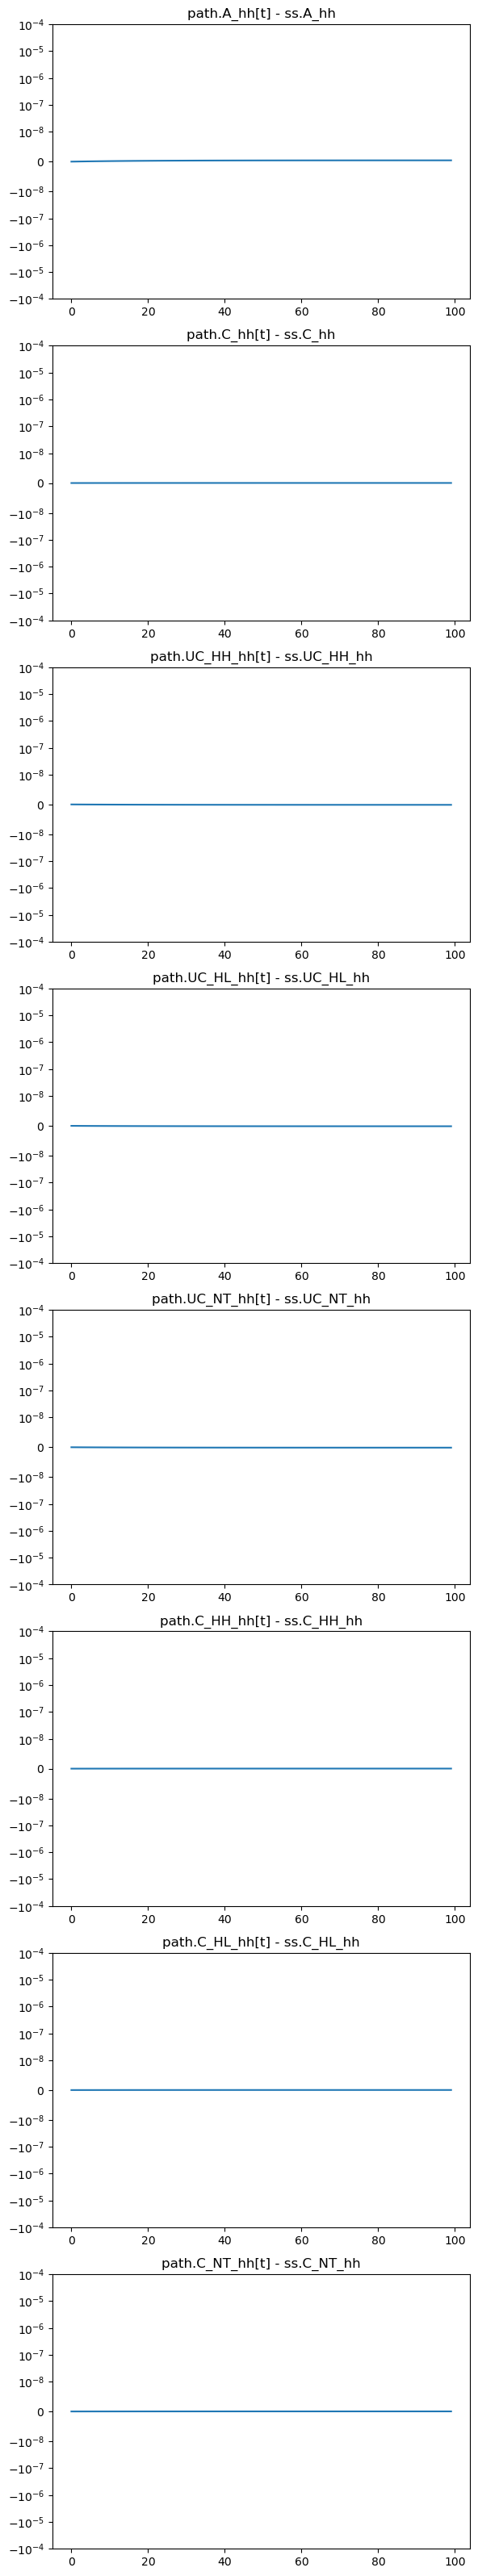

In [5]:
# Verifies the EGM backward solution and distribution simulation are consistent
model.test_hh_path()

## 4. Jacobians

In [3]:
# Confirms the GE block sequence produces a valid Jacobian
# (this is the main computational step)
model.compute_jacs(do_print=True)

household Jacobians:
one step deviation from steady state calculated in 0.0 secs
curly_Y and curly_D calculated for beta            in 0.2 secs
curly_Y and curly_D calculated for inc_HH          in 0.2 secs
curly_Y and curly_D calculated for inc_HL          in 0.2 secs
curly_Y and curly_D calculated for inc_NT          in 0.2 secs
curly_Y and curly_D calculated for ra              in 0.2 secs
curly_E calculated in 2.6 secs
builiding blocks combined in 0.1 secs
household Jacobian computed in 3.7 secs

full Jacobians:
full Jacobian to unknowns computed in 1.0 mins 21 secs [in evaluate_blocks(): 1.0 mins 20 secs]
full Jacobian to shocks computed in 1.5 secs [in evaluate_blocks(): 0.4 secs]


## 5. Quick sanity: US tariff shock
Verifies that the two tradeable sectors respond differently to the tariff
(sector asymmetry is the whole point of the extension).

In [7]:
import matplotlib.pyplot as plt

par.jump_tau_x = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_x  = 0.80

model.find_transition_path(shocks=['tau_x'], do_print=True, do_end_check=True)

finding the transition path:
 it =   0 -> max. abs. error = 4.80e-03
   7.83e-12 in NKWCHH_res
   7.83e-12 in NKWCHL_res
   7.83e-12 in NKWCNT_res
   8.92e-12 in clearing_YHH
   4.66e-12 in clearing_YHL
   4.78e-12 in clearing_YNT
   0.00e+00 in eu_Euler_res
   0.00e+00 in eu_NKPC_res
   0.00e+00 in eu_TR_res
   0.00e+00 in eu_LS_res
   4.16e-17 in eu_RC_res
   0.00e+00 in UIP_res
   0.00e+00 in us_Euler_res
   0.00e+00 in us_NKPC_res
   0.00e+00 in us_TR_res
   4.80e-03 in us_LS_res
   4.80e-03 in us_RC_res
   0.00e+00 in UIP_res_us
 it =   1 -> max. abs. error = 2.96e-05
   1.90e-06 in NKWCHH_res
   1.93e-06 in NKWCHL_res
   7.98e-07 in NKWCNT_res
   4.46e-06 in clearing_YHH
   2.39e-06 in clearing_YHL
   6.18e-07 in clearing_YNT
   3.28e-09 in eu_Euler_res
   5.56e-18 in eu_NKPC_res
   8.67e-19 in eu_TR_res
   1.82e-07 in eu_LS_res
   1.95e-07 in eu_RC_res
   2.38e-06 in UIP_res
   1.80e-06 in us_Euler_res
   2.08e-17 in us_NKPC_res
   4.34e-18 in us_TR_res
   2.96e-05 in us_LS_res


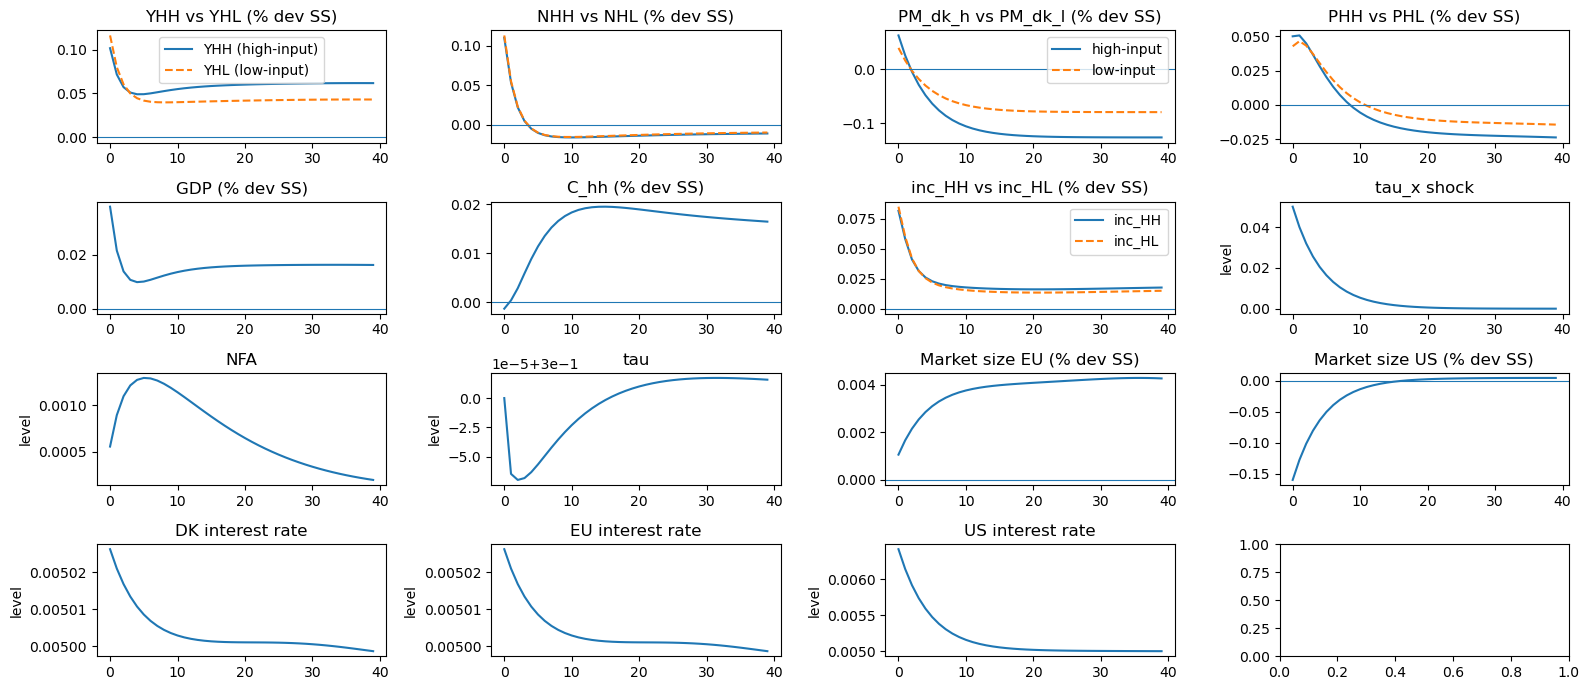

High-input sector hit harder: YES (as expected)


In [8]:
path = model.path
T_plot = 40
t = np.arange(T_plot)

fig, axes = plt.subplots(4, 4, figsize=(16, 7))

def pct(x, x_ss):
    return (x[:T_plot] / x_ss - 1) * 100

# Row 1: Production side
axes[0,0].set_title('YHH vs YHL (% dev SS)')
axes[0,0].plot(t, pct(path.YHH, ss.YHH), label='YHH (high-input)')
axes[0,0].plot(t, pct(path.YHL, ss.YHL), label='YHL (low-input)', ls='--')
axes[0,0].legend(); axes[0,0].axhline(0, lw=0.8)

axes[0,1].set_title('NHH vs NHL (% dev SS)')
axes[0,1].plot(t, pct(path.NHH, ss.NHH))
axes[0,1].plot(t, pct(path.NHL, ss.NHL), ls='--')
axes[0,1].axhline(0, lw=0.8)

axes[0,2].set_title('PM_dk_h vs PM_dk_l (% dev SS)')
axes[0,2].plot(t, pct(path.PM_dk_h, ss.PM_dk_h), label='high-input')
axes[0,2].plot(t, pct(path.PM_dk_l, ss.PM_dk_l), label='low-input', ls='--')
axes[0,2].legend(); axes[0,2].axhline(0, lw=0.8)

axes[0,3].set_title('PHH vs PHL (% dev SS)')
axes[0,3].plot(t, pct(path.PHH, ss.PHH))
axes[0,3].plot(t, pct(path.PHL, ss.PHL), ls='--')
axes[0,3].axhline(0, lw=0.8)

# Row 2: Aggregate
axes[1,0].set_title('GDP (% dev SS)')
axes[1,0].plot(t, pct(path.GDP, ss.GDP))
axes[1,0].axhline(0, lw=0.8)

axes[1,1].set_title('C_hh (% dev SS)')
axes[1,1].plot(t, pct(path.C_hh, ss.C_hh))
axes[1,1].axhline(0, lw=0.8)

axes[1,2].set_title('inc_HH vs inc_HL (% dev SS)')
axes[1,2].plot(t, pct(path.inc_HH, ss.inc_HH), label='inc_HH')
axes[1,2].plot(t, pct(path.inc_HL, ss.inc_HL), label='inc_HL', ls='--')
axes[1,2].legend(); axes[1,2].axhline(0, lw=0.8)

axes[1,3].set_title('tau_x shock')
axes[1,3].plot(t, path.tau_x[:T_plot])
axes[1,3].set_ylabel('level')

#Row 3
axes[2,0].set_title('NFA')
axes[2,0].plot(t, path.NFA[:T_plot])
axes[2,0].set_ylabel('level')

axes[2,1].set_title('tau')
axes[2,1].plot(t, path.tau[:T_plot])
axes[2,1].set_ylabel('level')

axes[2,2].set_title('Market size EU (% dev SS)')
axes[2,2].plot(t, pct(path.M_eu_s, ss.M_eu_s))
axes[2,2].axhline(0, lw=0.8)

axes[2,3].set_title('Market size US (% dev SS)')
axes[2,3].plot(t, pct(path.M_us_s, ss.M_us_s))
axes[2,3].axhline(0, lw=0.8)

#Row 4
axes[3,0].set_title('DK interest rate')
axes[3,0].plot(t, path.i[:T_plot])
axes[3,0].set_ylabel('level')

axes[3,1].set_title('EU interest rate')
axes[3,1].plot(t, path.i_eu[:T_plot])
axes[3,1].set_ylabel('level')

axes[3,2].set_title('US interest rate')
axes[3,2].plot(t, path.i_us[:T_plot])
axes[3,2].set_ylabel('level')


fig.tight_layout()
plt.show()

# Sector asymmetry check: high-input sector should be hit harder
dY_HH = pct(path.YHH, ss.YHH)[0]
dY_HL = pct(path.YHL, ss.YHL)[0]
#print(f'Impact on YHH: {dY_HH:.4f}%')
#print(f'Impact on YHL: {dY_HL:.4f}%')
asymmetry_ok = dY_HH < dY_HL   # high-input sector hurt more
print(f'High-input sector hit harder: {"YES (as expected)" if asymmetry_ok else "NO — check extension"}')

## Import tariff shock

In [4]:

par.jump_tau_m = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_m  = 0.80

model.find_transition_path(shocks=['tau_m'], do_print=True, do_end_check=True)

finding the transition path:
 it =   0 -> max. abs. error = 5.35e-04
   5.42e-05 in NKWCHH_res
   5.42e-05 in NKWCHL_res
   5.42e-05 in NKWCNT_res
   3.83e-04 in clearing_YHH
   7.07e-05 in clearing_YHL
   4.18e-04 in clearing_YNT
   0.00e+00 in eu_Euler_res
   0.00e+00 in eu_NKPC_res
   0.00e+00 in eu_TR_res
   5.35e-04 in eu_LS_res
   5.35e-04 in eu_RC_res
   2.22e-16 in UIP_res
   0.00e+00 in us_Euler_res
   0.00e+00 in us_NKPC_res
   0.00e+00 in us_TR_res
   0.00e+00 in us_LS_res
   4.16e-17 in us_RC_res
   2.22e-16 in UIP_res_us
 it =   1 -> max. abs. error = 5.84e-06
   2.02e-06 in NKWCHH_res
   5.68e-07 in NKWCHL_res
   5.84e-06 in NKWCNT_res
   8.47e-07 in clearing_YHH
   7.81e-07 in clearing_YHL
   5.06e-07 in clearing_YNT
   4.56e-08 in eu_Euler_res
   7.75e-18 in eu_NKPC_res
   8.67e-19 in eu_TR_res
   3.69e-07 in eu_LS_res
   3.11e-07 in eu_RC_res
   1.07e-07 in UIP_res
   3.28e-09 in us_Euler_res
   5.49e-18 in us_NKPC_res
   8.67e-19 in us_TR_res
   1.45e-08 in us_LS_res


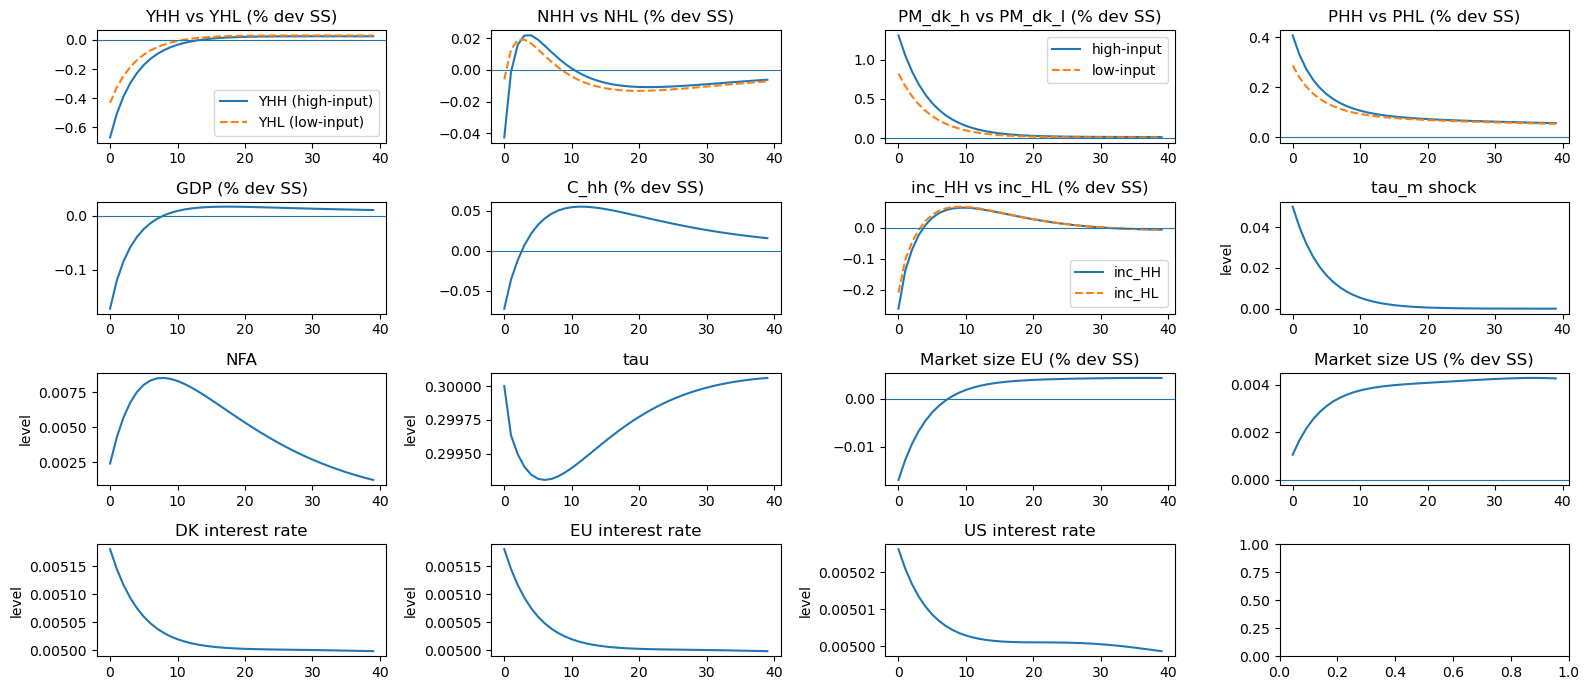

High-input sector hit harder: YES (as expected)


In [5]:
path = model.path
T_plot = 40
t = np.arange(T_plot)

fig, axes = plt.subplots(4, 4, figsize=(16, 7))

def pct(x, x_ss):
    return (x[:T_plot] / x_ss - 1) * 100

# Row 1: Production side
axes[0,0].set_title('YHH vs YHL (% dev SS)')
axes[0,0].plot(t, pct(path.YHH, ss.YHH), label='YHH (high-input)')
axes[0,0].plot(t, pct(path.YHL, ss.YHL), label='YHL (low-input)', ls='--')
axes[0,0].legend(); axes[0,0].axhline(0, lw=0.8)

axes[0,1].set_title('NHH vs NHL (% dev SS)')
axes[0,1].plot(t, pct(path.NHH, ss.NHH))
axes[0,1].plot(t, pct(path.NHL, ss.NHL), ls='--')
axes[0,1].axhline(0, lw=0.8)

axes[0,2].set_title('PM_dk_h vs PM_dk_l (% dev SS)')
axes[0,2].plot(t, pct(path.PM_dk_h, ss.PM_dk_h), label='high-input')
axes[0,2].plot(t, pct(path.PM_dk_l, ss.PM_dk_l), label='low-input', ls='--')
axes[0,2].legend(); axes[0,2].axhline(0, lw=0.8)

axes[0,3].set_title('PHH vs PHL (% dev SS)')
axes[0,3].plot(t, pct(path.PHH, ss.PHH))
axes[0,3].plot(t, pct(path.PHL, ss.PHL), ls='--')
axes[0,3].axhline(0, lw=0.8)

# Row 2: Aggregate
axes[1,0].set_title('GDP (% dev SS)')
axes[1,0].plot(t, pct(path.GDP, ss.GDP))
axes[1,0].axhline(0, lw=0.8)

axes[1,1].set_title('C_hh (% dev SS)')
axes[1,1].plot(t, pct(path.C_hh, ss.C_hh))
axes[1,1].axhline(0, lw=0.8)

axes[1,2].set_title('inc_HH vs inc_HL (% dev SS)')
axes[1,2].plot(t, pct(path.inc_HH, ss.inc_HH), label='inc_HH')
axes[1,2].plot(t, pct(path.inc_HL, ss.inc_HL), label='inc_HL', ls='--')
axes[1,2].legend(); axes[1,2].axhline(0, lw=0.8)

axes[1,3].set_title('tau_m shock')
axes[1,3].plot(t, path.tau_m[:T_plot])
axes[1,3].set_ylabel('level')

#Row 3
axes[2,0].set_title('NFA')
axes[2,0].plot(t, path.NFA[:T_plot])
axes[2,0].set_ylabel('level')

axes[2,1].set_title('tau')
axes[2,1].plot(t, path.tau[:T_plot])
axes[2,1].set_ylabel('level')

axes[2,2].set_title('Market size EU (% dev SS)')
axes[2,2].plot(t, pct(path.M_eu_s, ss.M_eu_s))
axes[2,2].axhline(0, lw=0.8)

axes[2,3].set_title('Market size US (% dev SS)')
axes[2,3].plot(t, pct(path.M_us_s, ss.M_us_s))
axes[2,3].axhline(0, lw=0.8)

#Row 4
axes[3,0].set_title('DK interest rate')
axes[3,0].plot(t, path.i[:T_plot])
axes[3,0].set_ylabel('level')

axes[3,1].set_title('EU interest rate')
axes[3,1].plot(t, path.i_eu[:T_plot])
axes[3,1].set_ylabel('level')

axes[3,2].set_title('US interest rate')
axes[3,2].plot(t, path.i_us[:T_plot])
axes[3,2].set_ylabel('level')


fig.tight_layout()
plt.show()

# Sector asymmetry check: high-input sector should be hit harder
dY_HH = pct(path.YHH, ss.YHH)[0]
dY_HL = pct(path.YHL, ss.YHL)[0]
#print(f'Impact on YHH: {dY_HH:.4f}%')
#print(f'Impact on YHL: {dY_HL:.4f}%')
asymmetry_ok = dY_HH < dY_HL   # high-input sector hurt more
print(f'High-input sector hit harder: {"YES (as expected)" if asymmetry_ok else "NO — check extension"}')

## Import and Export shock

In [ ]:

par.jump_tau_m = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_m  = 0.80
par.jump_tau_x = 0.05   # +5pp US tariff on DK/EA imports
par.rho_tau_x  = 0.80

model.find_transition_path(shocks=['tau_m', 'tau_x'], do_print=True, do_end_check=True)